In [7]:
from plastic_neuron import PlasticNeuron
from abstract_neuron import AbstractNeuron
from neuron_utils import NeuronUtils
from neuron_plots import NeuronPlots
import matplotlib.pyplot as plt
from neuron import h
import numpy as np
import pandas as pd

# Subthreshold LTP with and without the electric field

The neuron has 10 synapses. All synapses receive potentiating inputs of 100 Hz for 1000 ms, starting at 1000 ms and ending at 2000 ms. The neuron is either in TI electric field (5 Hz TI: 1005 Hz and 1000 Hz) or receives no external electric field stimulation. Electric field is active only during LTP induction protocol (it is off during both test stimuli).

The test stimulus (a single stimulus to all synapses) is provided at 100 ms (before LTP protocol) and at 2500 ms (after LTP protocol).

In [8]:
test_stimulus_1 = 100
test_stimulus_2 = 2500

In [9]:
idxs = np.arange(0, 20)
conductance = "0.000070"
types = {
    "No TI": "conductance_ltp",
    "5 Hz": "conductance_ltp_ef_5"
}

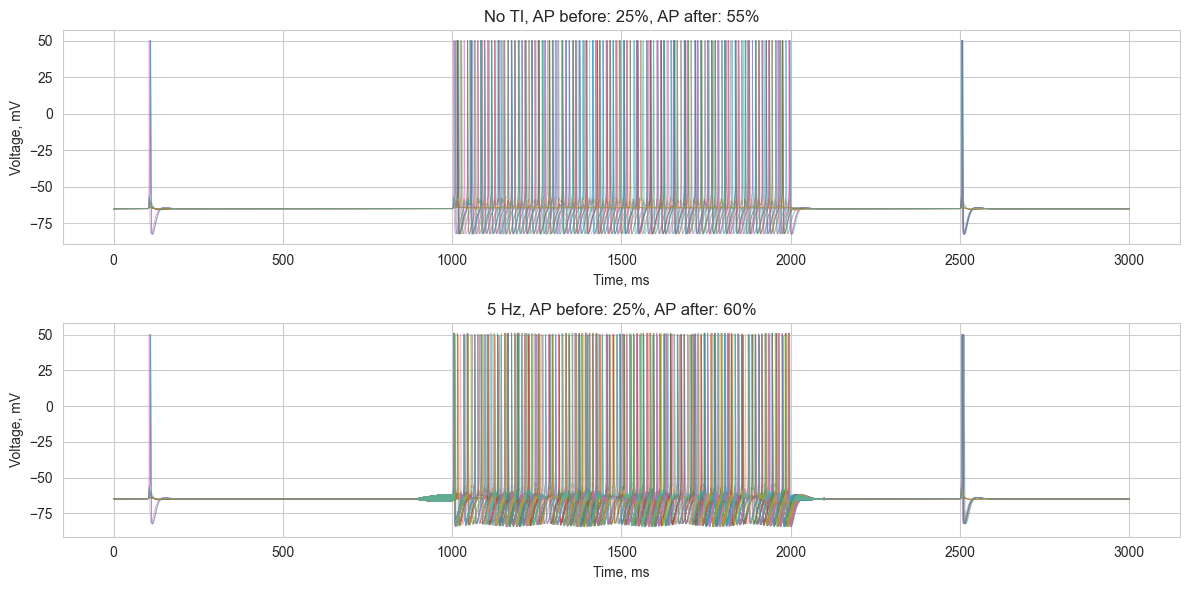

In [10]:
fig, axs = plt.subplots(nrows = len(types.keys()), ncols = 1, figsize = (12, len(types.keys()) * 3))

for key, ax in zip(types.keys(), axs):
    type = types[key]
    spike_before = 0
    spike_after = 0
    for idx in idxs:
        voltage = pd.read_csv(f"output/temporal-interference/{type}/{idx}/{conductance}/voltage.csv")

        ax.plot(
            voltage.Time,
            voltage.Voltage,
            linewidth = 0.5,
            alpha = 0.5
        )

        epsp_1 = np.array(voltage.Voltage[np.where(np.logical_and(voltage.Time > test_stimulus_1 - 50, voltage.Time < test_stimulus_1 + 150))[0]].tolist())
        epsp_2 = np.array(voltage.Voltage[np.where(np.logical_and(voltage.Time > test_stimulus_2 - 50, voltage.Time < test_stimulus_2 + 150))[0]].tolist())

        spike_before += np.any(epsp_1 > -20)
        spike_after += np.any(epsp_2 > -20)

    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Voltage, mV")
    ax.set_title(f"{key}, AP before: {round(spike_before / len(idxs) * 100)}%, AP after: {round(spike_after / len(idxs) * 100)}%")

fig.tight_layout()
plt.show()

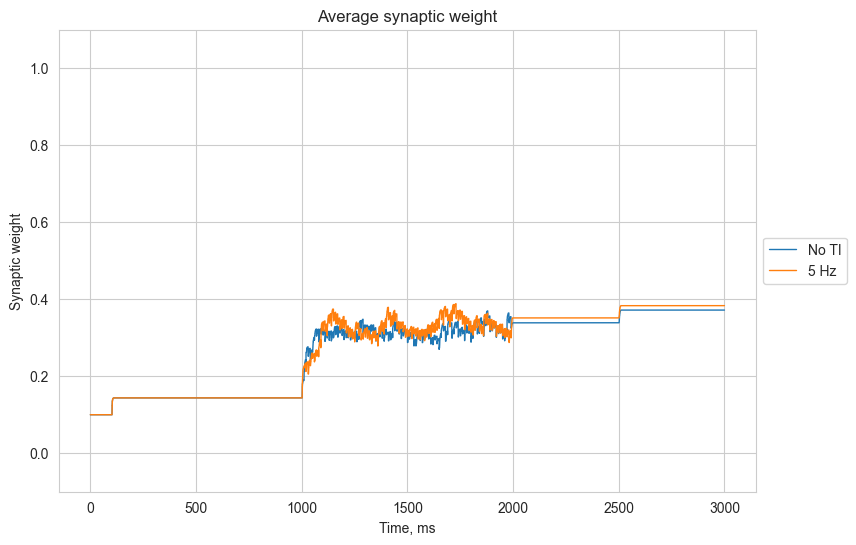

In [11]:
plt.figure(figsize = (9, 6))

for key in types.keys():
    type = types[key]
    weights = []
    time = []
    for idx in idxs:
        synapse_weights = pd.read_csv(f"output/temporal-interference/{type}/{idx}/{conductance}/synapse_weights.csv", index_col = 0)
        synapses = [ f"Synapse{i}" for i in range(0, 10) ]

        idx_weights = np.array([ synapse_weights[synapse] for synapse in synapses ])
        weights.append(idx_weights)
        time = synapse_weights.Time

    weights = np.concatenate(weights)
    plt.plot(time, weights.mean(axis = 0), label = key, linewidth = 1)

plt.ylim(-0.1, 1.1)
plt.title("Average synaptic weight")
plt.xlabel("Time, ms")
plt.ylabel("Synaptic weight")
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.grid(True)

plt.show()

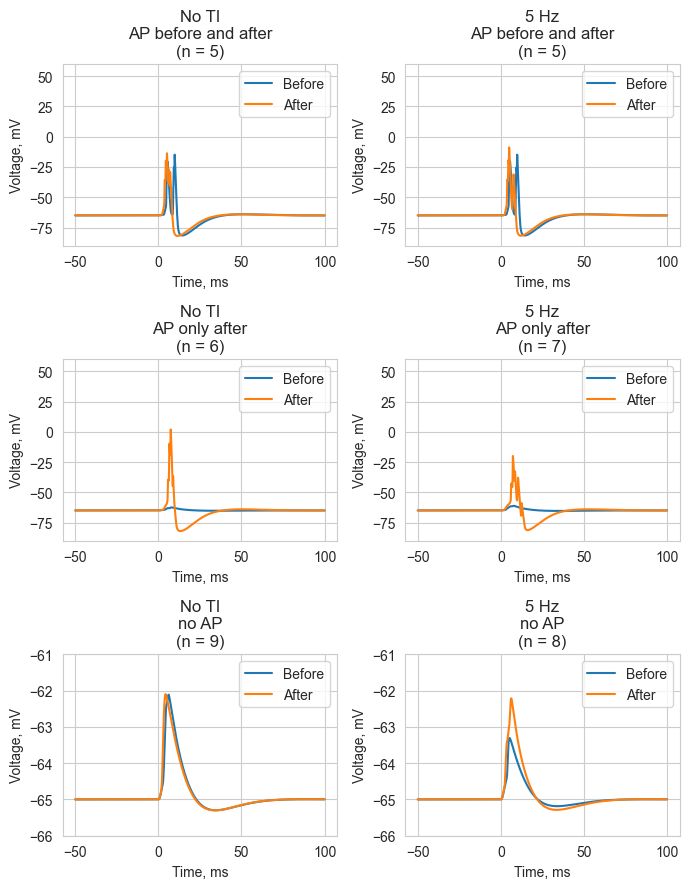

In [12]:
time_before = 50
time_after = 100

fig, axs = plt.subplots(ncols = len(types.keys()), nrows = 3, figsize = (len(types.keys()) * 3.5, 9))

epsp_both_list = []
epsp_after_list = []
epsp_no_list = []

for i, key in enumerate(types.keys()):
    type = types[key]
    
    epsp_before_has_ap_both = []
    epsp_after_has_ap_both = []

    epsp_before_has_ap_after = []
    epsp_after_has_ap_after = []

    epsp_before_no_ap = []
    epsp_after_no_ap = []

    for idx in idxs:
        voltage = pd.read_csv(f"output/temporal-interference/{type}/{idx}/{conductance}/voltage.csv")

        epsp_before = np.array(voltage.Voltage[np.where(np.logical_and(voltage.Time > test_stimulus_1 - time_before, voltage.Time < test_stimulus_1 + time_after))[0]].tolist())
        epsp_after = np.array(voltage.Voltage[np.where(np.logical_and(voltage.Time > test_stimulus_2 - time_before, voltage.Time < test_stimulus_2 + time_after))[0]].tolist())

        has_ap_before = np.any(epsp_before > -20)
        has_ap_after = np.any(epsp_after > -20)

        # if key == "No TI":
        if has_ap_before and has_ap_after:
            epsp_both_list.append(idx)
            epsp_before_has_ap_both.append(epsp_before)
            epsp_after_has_ap_both.append(epsp_after)
            continue

        if not has_ap_before and has_ap_after:
            epsp_after_list.append(idx)
            epsp_before_has_ap_after.append(epsp_before)
            epsp_after_has_ap_after.append(epsp_after)
            continue

        if not has_ap_before and not has_ap_after:
            epsp_no_list.append(idx)
            epsp_before_no_ap.append(epsp_before)
            epsp_after_no_ap.append(epsp_after)
            continue
        
        # else:
        #     if idx in epsp_both_list:
        #         epsp_before_has_ap_both.append(epsp_before)
        #         epsp_after_has_ap_both.append(epsp_after)
        #         continue
        #     
        #     if idx in epsp_after_list:
        #         epsp_before_has_ap_after.append(epsp_before)
        #         epsp_after_has_ap_after.append(epsp_after)
        #         continue
        #     
        #     if idx in epsp_no_list:
        #         epsp_before_no_ap.append(epsp_before)
        #         epsp_after_no_ap.append(epsp_after)
        #         continue

        print("Unhandled case!")
        print(f"Has AP before: {has_ap_before}")
        print(f"Has AP after: {has_ap_after}")

    time = np.arange(-time_before, time_after + 0.025, 0.025)

    if len(epsp_before_has_ap_both) > 0:
        count = len(epsp_before_has_ap_both)
        epsp_before_has_ap_both = np.stack(epsp_before_has_ap_both).mean(axis = 0)
        epsp_after_has_ap_both = np.stack(epsp_after_has_ap_both).mean(axis = 0)

        ax = axs[0][i]
        ax.set_ylabel("Voltage, mV")
        ax.set_xlabel("Time, ms")
        ax.plot(
            time[:len(epsp_before_has_ap_both)],
            epsp_before_has_ap_both,
            label = "Before"
        )
        ax.plot(
            time[:len(epsp_after_has_ap_both)],
            epsp_after_has_ap_both,
            label = "After"
        )

        ax.set_title(f"{key}\nAP before and after\n(n = {count})")
        ax.legend(loc = "upper right")
        ax.set_ylim(-90, 60)
        ax.grid(True)

    if len(epsp_before_has_ap_after) > 0:
        count = len(epsp_before_has_ap_after)
        epsp_before_has_ap_after = np.stack(epsp_before_has_ap_after).mean(axis = 0)
        epsp_after_has_ap_after = np.stack(epsp_after_has_ap_after).mean(axis = 0)

        ax = axs[1][i]
        ax.set_ylabel("Voltage, mV")
        ax.set_xlabel("Time, ms")
        ax.plot(
            time[:len(epsp_before_has_ap_after)],
            epsp_before_has_ap_after,
            label = "Before"
        )
        ax.plot(
            time[:len(epsp_after_has_ap_after)],
            epsp_after_has_ap_after,
            label = "After"
        )

        ax.set_title(f"{key}\nAP only after\n(n = {count})")
        ax.legend(loc = "upper right")
        ax.set_ylim(-90, 60)
        ax.grid(True)

    if len(epsp_before_no_ap) > 0:
        count = len(epsp_before_no_ap)
        epsp_before_no_ap = np.stack(epsp_before_no_ap).mean(axis = 0)
        epsp_after_no_ap = np.stack(epsp_after_no_ap).mean(axis = 0)

        ax = axs[2][i]
        ax.set_ylabel("Voltage, mV")
        ax.set_xlabel("Time, ms")
        ax.plot(
            time[:len(epsp_before_no_ap)],
            epsp_before_no_ap,
            label = "Before"
        )
        ax.plot(
            time[:len(epsp_after_no_ap)],
            epsp_after_no_ap,
            label = "After"
        )

        ax.set_title(f"{key}\nno AP\n(n = {count})")
        ax.legend(loc = "upper right")
        ax.set_ylim(-66, -61)
        ax.grid(True)

fig.tight_layout()
plt.show()